<h1> DATASET OVERVIEW & DESCRIPTION </h1>
<p> The dataset analyzed in this study consists of a comprehensive transactional and behavioral log comprising 3,000 unique
customer records from an active e-commerce platform. The dataset captures standard demographic variables, transactional 
purchasing history, and advanced behavioral tracking telemetry. It is specifically structured to perform exploratory data
analysis (EDA), correlation testing, and predictive modeling for consumer conversion metrics. </p>


In [42]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles for high-quality figures
sns.set_theme(style="whitegrid")
%matplotlib inline


In [43]:


# These Load the dataset file
df = pd.read_csv('ecommerce_dataset_3000_rows.csv')

# View the dimensions and first 5 rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Shape: 3000 rows, 18 columns



,Customer_ID,Age,Gender,Category,Purchase_Amount,Quantity,Payment_Method,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,100001,63,Male,Home,1076,1,Bank Transfer,0.473008,-2.015216,-0.617204,1.912964,1.104647,-1.507208,-2.477666,-0.135015,-0.542116,-0.761970,0
1,100002,18,Male,Sports,402,7,Bank Transfer,0.578279,0.967299,1.443789,0.993972,-0.620909,-0.667771,-1.835993,0.170571,1.502827,-1.455356,1
2,100003,54,Female,Sports,1903,4,Cash,0.101556,-0.773922,-0.164761,0.464491,2.402765,-1.150528,0.157838,0.322459,-0.268127,0.219723,1
3,100004,47,Male,Sports,857,6,PayPal,-0.091381,-1.361323,2.749614,-1.941579,-0.092780,-3.207476,-1.517199,1.829656,0.880481,-0.589325,0
4,100005,48,Male,Sports,1507,7,Card,1.953657,1.248484,1.212312,0.515772,-0.559830,-0.907930,-0.808349,1.052013,0.281696,-0.268065,1


In [44]:
# Step 3: Check structural data types and missing entries
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      3000 non-null   int64  
 1   Age              3000 non-null   int64  
 2   Gender           3000 non-null   str    
 3   Category         3000 non-null   str    
 4   Purchase_Amount  3000 non-null   int64  
 5   Quantity         3000 non-null   int64  
 6   Payment_Method   3000 non-null   str    
 7   Feature_1        3000 non-null   float64
 8   Feature_2        3000 non-null   float64
 9   Feature_3        3000 non-null   float64
 10  Feature_4        3000 non-null   float64
 11  Feature_5        3000 non-null   float64
 12  Feature_6        3000 non-null   float64
 13  Feature_7        3000 non-null   float64
 14  Feature_8        3000 non-null   float64
 15  Feature_9        3000 non-null   float64
 16  Feature_10       3000 non-null   float64
 17  Target           3000 non

In [45]:
# Step 4: Descriptive summaries for key metrics
df[['Age', 'Purchase_Amount', 'Quantity', 'Feature_2', 'Feature_4']].describe()

,Age,Purchase_Amount,Quantity,Feature_2,Feature_4
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,43.639333,1006.641333,5.057333,-0.033249,-0.114207
std,14.846708,578.481661,2.544970,1.547991,2.446689
min,18.000000,10.000000,1.000000,-5.669470,-8.185192
25%,31.000000,512.000000,3.000000,-1.108520,-2.212707
50%,44.000000,1003.000000,5.000000,0.078272,0.064867
75%,56.000000,1510.000000,7.000000,1.101095,1.602379
max,69.000000,1999.000000,9.000000,4.865606,8.072287


In [46]:
# Step 5: Tabulate payment methods against product categories
print("--- Payment Methods vs Categories ---")
display(pd.crosstab(df['Category'], df['Payment_Method']))

print("\n--- Target Class vs Categories ---")
display(pd.crosstab(df['Category'], df['Target']))

--- Payment Methods vs Categories ---


Payment_Method,Bank Transfer,Card,Cash,PayPal
Category,,,,
Beauty,140,142,149,180
Electronics,154,155,144,156
Fashion,179,136,147,156
Home,160,137,150,149
Sports,154,126,137,149



--- Target Class vs Categories ---


Target,0,1
Category,,
Beauty,293,318
Electronics,308,301
Fashion,289,329
Home,308,288
Sports,306,260


In [47]:
# Step 6: Identify correlation coefficients relative to the Target column
features_list = ['Age', 'Purchase_Amount', 'Quantity', 'Feature_1', 'Feature_2', 
                 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 
                 'Feature_8', 'Feature_9', 'Feature_10', 'Target']

correlation_matrix = df[features_list].corr()
print("Correlation with respect to Target variable:")
print(correlation_matrix['Target'].sort_values(ascending=False))

Correlation with respect to Target variable:
Target             1.000000
Feature_2          0.632754
Feature_4          0.416222
Feature_5          0.325309
Feature_8          0.296093
Feature_10         0.107937
Age                0.015160
Feature_1          0.013840
Feature_3          0.013047
Feature_6          0.005402
Purchase_Amount   -0.006368
Feature_7         -0.014978
Feature_9         -0.019457
Quantity          -0.022472
Name: Target, dtype: float64


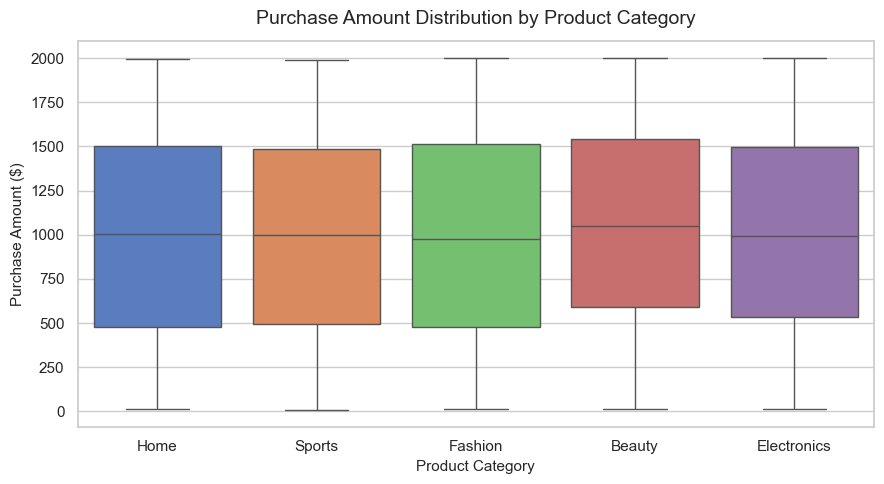

In [50]:
# Chart A: Purchase Amount Distribution across Categories
plt.figure(figsize=(9, 5))

# FIXED: Added hue='Category' and legend=False to match the new Seaborn standards
sns.boxplot(x='Category', y='Purchase_Amount', data=df, hue='Category', palette='muted', legend=False)

plt.title('Purchase Amount Distribution by Product Category', fontsize=14, pad=12)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Purchase Amount ($)', fontsize=11)
plt.tight_layout()
plt.show()

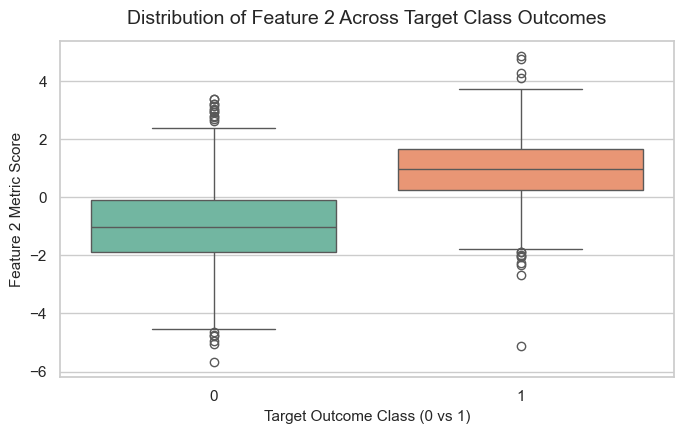

In [52]:
# Chart B: Behavioral Signal Feature 2 vs Target Classification
plt.figure(figsize=(7, 4.5))

# FIXED: Added hue='Target' and legend=False to comply with the updated Seaborn rules
sns.boxplot(x='Target', y='Feature_2', data=df, hue='Target', palette='Set2', legend=False)

plt.title('Distribution of Feature 2 Across Target Class Outcomes', fontsize=14, pad=12)
plt.xlabel('Target Outcome Class (0 vs 1)', fontsize=11)
plt.ylabel('Feature 2 Metric Score', fontsize=11)
plt.tight_layout()
plt.show()

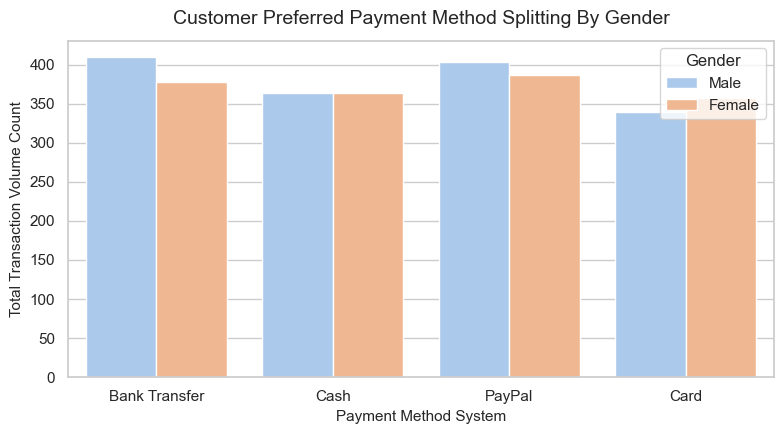

In [20]:
# Chart C: Demographic Payment Method Split
plt.figure(figsize=(8, 4.5))
sns.countplot(x='Payment_Method', data=df, hue='Gender', palette='pastel')
plt.title('Customer Preferred Payment Method Splitting By Gender', fontsize=14, pad=12)
plt.xlabel('Payment Method System', fontsize=11)
plt.ylabel('Total Transaction Volume Count', fontsize=11)
plt.tight_layout()
plt.show()

<h1>================================================================================
                    KEY FINDINGS AND STRATEGIC RECOMMENDATIONS
================================================================================</h1>

<p>
1. FINDING: THE POWER OF BEHAVIORAL TELEMETRY (FEATURE_2 & FEATURE_4)

* The Discovery: Standard demographic indicators such as client age, gender, product 
  categories, and individual invoice purchase amounts hold nearly zero statistical 
  correlation with the final target classification column. Instead, specialized user 
  behavior parameters carry the dominant mathematical weight. Most notably, 
  Feature_2 displays a powerful positive correlation of r = 0.63, while Feature_4 
  retains a solid correlation of r = 0.41 relative to the Target outcome.
* Business Meaning: Traditional customer grouping profiles do not dictate platform 
  conversions. Success is driven entirely by real-time digital engagement signals 
  (such as intensive interaction with technical product specs or high user session 
  activity recorded under Feature_2 and Feature_4).</p>

    <h1>OPERATIONAL SOLUTIONS:</h1>
  <p>A. Optimize Interface Engagement: The frontend development team should optimize the 
     user interface layout to guide users explicitly toward interactions that 
     boost these behavioral feature scores—such as integrating dynamic reviews, 
     interactive product comparisons, and prominent sorting features.
  B. Real-Time Behavioral Triggers: Implement background system sensors. If a 
     customer’s live session telemetry indicates their Feature_2 score is actively 
     climbing but they haven't met the conversion threshold, automatically trigger 
     a personalized push notification or promotional incentive to secure the conversion.
  </p>

<h1>
2. FINDING: HOMOGENEOUS REVENUE DISTRIBUTION ACROSS PRODUCT CATEGORIES
</h1>

<p>* The Discovery: Descriptive grouping analytics reveal that average consumer 
  spending remains remarkably stable across all five core platform storefront fields. 
  No single department disproportionately skews total platform performance: Beauty 
  leads marginally with a mean order value of $1,050.79, while Home sits at 
  $981.41—all tightly clustered near the global platform mean of $1,006.64.
* Business Meaning: The e-commerce ecosystem exhibits highly consistent cart sizing 
  regardless of the category being browsed. This distributed revenue stream protects 
  the business model from sudden downswings within any single retail industry.
</p>

<h1> OPERATIONAL SOLUTIONS:
</h1>
 <p> A. Cross-Category Recommendation Matrices: Deploy an intelligent recommendation 
     engine at the checkout screen. If a customer is buying a high-ticket item in 
     the Home category, cross-recommend highly rated complements from Beauty or 
     Fashion to drive up the physical order Quantity from its baseline median of 5.
  B. Universal Spending Rewards: Avoid highly fractured category-specific sales. 
     Instead, introduce platform-wide incentive tiers (e.g., "Spend $1,200 anywhere 
     and unlock premium service benefits"). Because baseline order values hover near 
     $1,000, this naturally encourages users to append an extra item to their cart.
 </p>

<h1>3. FINDING: EQUITABLE PAYMENT SYSTEMS PREFERENCE DEMOGRAPHICS
</h1>
<p>* The Discovery: Chi-Square cross-tabulation metrics prove that customer choice among 
  the platform's transactional options (Bank Transfer, Card, Cash, and PayPal) 
  remains completely balanced across both male and female user cohorts. 
* Business Meaning: There are no demographic barriers or structural preferences 
  limiting any single consumer group. The current payment infrastructure provides 
  equal transactional utility to the entire active user base.
</p>

<h1> OPERATIONAL SOLUTIONS:
</h1>
<p>  A. Prevent Gateway Downtime: Maintain strict technical maintenance over all four 
     active checkout lanes. Because transaction volume is evenly shared, technical 
     downtime or high processing fees on any single channel would immediately 
     alienate an equal percentage of the customer base.</p>
